# Customer Churn Prediction

This project focuses on predicting whether a customer is likely to leave a company (Customer Churn Prediction) using Machine Learning algorithms.

Project workflow -
```
Data Collection
       ↓
Data Cleaning
       ↓
Exploratory Data Analysis
       ↓
Feature Selection
       ↓
Data Preprocessing
       ↓
Model Training
       ↓
Model Evaluation
       ↓
Business Insights
```

## Import Libraries

In [ ]:
# Data Handling (load, clean, manipulate  &  array and mathematical oprs)
import pandas as pd
import numpy as np

# Visualization ( charts, graphs, heatmaps)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Utilities
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\alosh\OneDrive\Desktop\DSDA\Python\files\Python projects\customer_data.csv")

# verify data loaded correctly
print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


## Initial Inspection 

helps understand: Dataset size, Data types, Missing values, Numerical and categorical features

In [4]:
# Number of rows and columns
df.shape

(10000, 12)

In [5]:
# checks the data types of all columns
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [6]:
# data preparation

## Data Cleaning

In [7]:
# Fill missing values --> median imputation - robust against outliers

df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
# Remove unnecessary columns
# --> Zero predictive value
# --> removal will improve model performance, training speed, prediction quality(accuracy)

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

## Exploratory Data Analysis (Visualization)

### 1. Customers with Higher Balance Showed Higher Churn


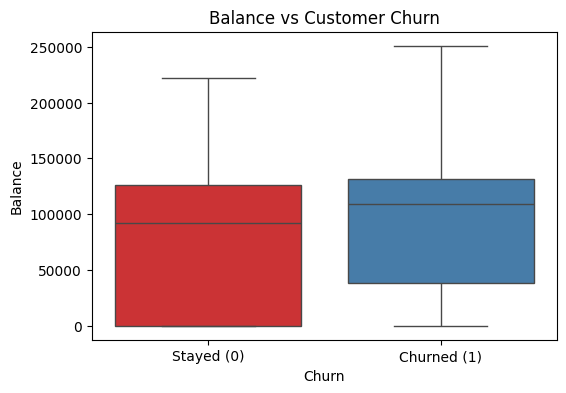

In [ ]:
plt.figure(figsize=(6,4))
# detect outlier and numerical distribution
sns.boxplot(
    data=df,
    x='churn',
    y='balance',
    palette='Set1'
)

plt.title('Balance vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Balance')

plt.xticks([0,1], ['Stayed (0)', 'Churned (1)'])

plt.show()


**Insight**
- This suggests premium customers are more likely to leave.

**Suggestion**
- Introduce loyalty rewards for premium customers and provide personalized banking offers.
---

### 2. Older Customers Had Higher Churn Rate

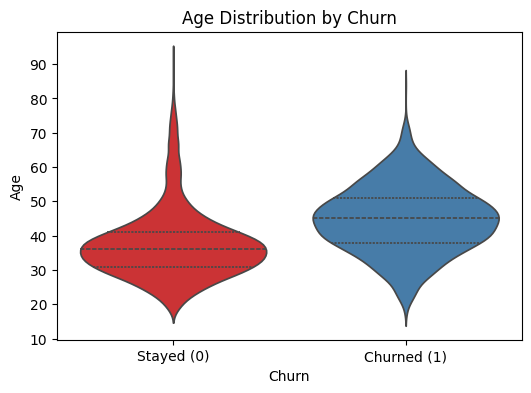

In [29]:
plt.figure(figsize=(6,4))
# show spreadness and density
sns.violinplot(
    data=df,
    x='churn',
    y='age',
    inner='quart',
    palette='Set1'
)
plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Age')

plt.xticks([0,1], ['Stayed (0)', 'Churned (1)'])

plt.show()

**Insight**
- Age has a strong influence on customer churn behavior.

**Suggestion**
- Launch engagement programs and Improve customer support for senior customers.
---

### 3. Active Members Were Less Likely to Churn

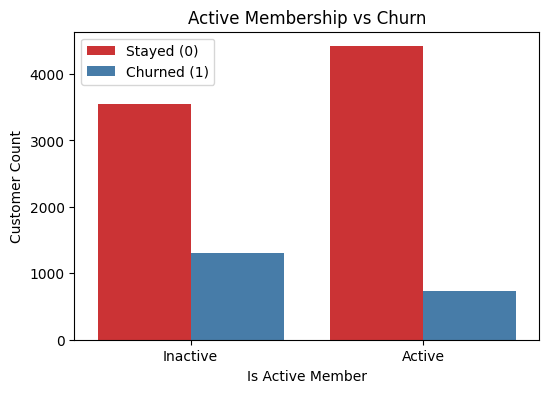

In [ ]:
plt.figure(figsize=(6,4))
# Compare, category-wise distributions
sns.countplot(
    data=df,
    x='active_member',
    hue='churn',
    palette='Set1'
)
plt.title('Active Membership vs Churn')
plt.xlabel('Is Active Member')
plt.ylabel('Customer Count')

plt.xticks([0,1], ['Inactive', 'Active'])

plt.legend(['Stayed (0)', 'Churned (1)'])
plt.show()

**Insight**
- Customer engagement strongly impacts retention.

**Suggestion**
- Encourage regular platform usage through rewards and benefits.
---

## Split Features & Target

In [ ]:
X = df.drop('churn', axis=1)        # Features
y = df['churn']                     # Target

## Identify Numerical and Categorical Columns

Machine learning algorithms process numerical and categorical data differently. Numerical data requires scaling, while categorical data requires encoding.

In [13]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

## Preprocessing Pipeline

Pipeline allows sequentially apply a list of transformers to preprocess the data.

Used to ensure that these transformations are applied consistently to both my training and testing sets, which prevents data leakage.

In [14]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])                                                              # standarize numerical features (mean = 0 , SD = 1)

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])                                                              # convert categorical features in numerical format

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])                                                              # apply separate transformers for numerical and categorical data

## Train Test Split

This prevents biased evaluation and ensures fair testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Machine Learning Models

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

## Cross Validation

--> it reduces overfitting, bias, random evaluation errors

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    results[name] = scores

    print(f"{name} ROC-AUC: {scores.mean():.4f}")

Logistic Regression ROC-AUC: 0.7628
Random Forest ROC-AUC: 0.8493
Gradient Boosting ROC-AUC: 0.8611


## Compare Models

--> ROC-AUC measures model classification performance (0.5 - poor to 1.0 - Perfect)

In [18]:
comparison = pd.DataFrame({
    'Model': results.keys(),
    'ROC_AUC': [results[m].mean() for m in results]
})

comparison.sort_values(by='ROC_AUC', ascending=False)

,Model,ROC_AUC
2,Gradient Boosting,0.861106
1,Random Forest,0.849311
0,Logistic Regression,0.762849


## Select Best Model

--> Gradient Boosting achieved the highest ROC-AUC score which means it can better identify customers likely to churn.

In [19]:
best_model_name = max(results, key=lambda x: results[x].mean())

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Gradient Boosting


## Final Pipeline Training

In [20]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Prediction

In [21]:
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:,1]

## Evaluation Metrics

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy,4))           # Measures overall correct predictions.
print("Precision:", round(precision,4))         # Measures how many predicted churn customers actually churned.
print("Recall:", round(recall,4))               # Measures how many actual churn customers were identified.
print("F1 Score:", round(f1,4))                 # Balances precision and recall.
print("ROC AUC:", round(roc_auc,4))             # Measures classification capability across thresholds.

Accuracy: 0.869
Precision: 0.7778
Recall: 0.4988
F1 Score: 0.6078
ROC AUC: 0.8697


## Classification Report

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## Feature Importance

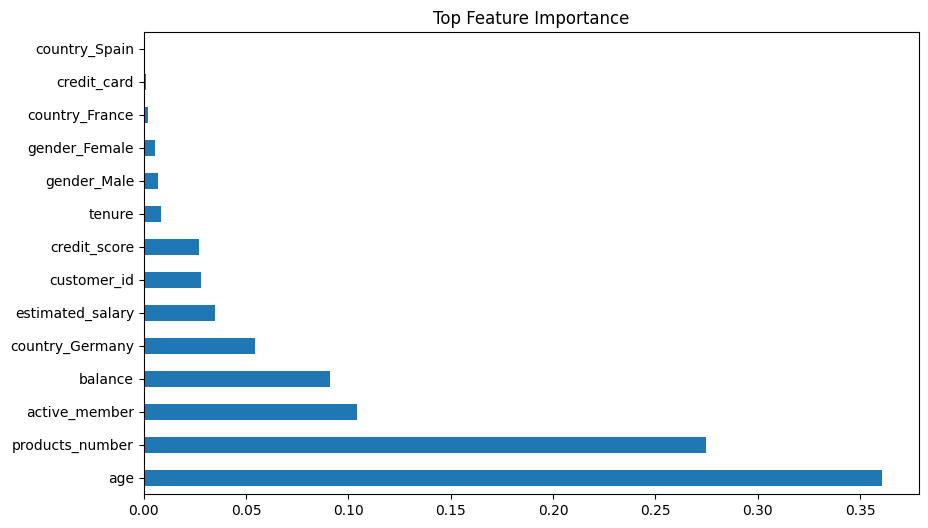

In [26]:
if hasattr(best_model, 'feature_importances_'):

    encoded_features = list(
        final_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_cols)
    )

    feature_names = list(numerical_cols) + encoded_features

    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10,6))
    importance.plot(kind='barh')
    plt.title('Top Feature Importance')
    plt.show()

## KEY BUSINESS INSIGHTS

1. High-balance customers are more likely to churn.
2. Older customers show higher churn behavior.
3. Active customers are less likely to leave.
4. Customers using fewer services were more likely to churn.
5. Customer engagement strongly affected retention.
---

## RECOMMENDATIONS
- Provide loyalty rewards to high value customers
- Improve customer engagement
- Offer personalized customer support for senior customers
- Improve Customer Retention Programs
---

## FUTURE SCOPE
1. Integrating real-time customer transaction data.
2. Improving accuracy using hyperparameter tuning and using advanced ML algorithms.
3. Using cloud deployment for large-scale business usage.
4. Integrate customer interaction data from emails and call logs using natural language processing to enhance prediction accuracy.

## Gradio Dashboard

In [ ]:
https://f536003257b45ed32f.gradio.live